POPULATION  (N = 10000)
  Population mean  (mu)    = 64.96
  Population SD    (sigma) = 12.02
SAMPLE      (n = 50)
  Sample mean      (x-bar) = 65.70
  Sample SD        (s)     = 12.67
Sampling error (x-bar - mu) = 0.74

Means of 5 different random samples of size 50:
  Sample 1: mean = 64.14
  Sample 2: mean = 65.54
  Sample 3: mean = 64.92
  Sample 4: mean = 65.02
  Sample 5: mean = 64.74


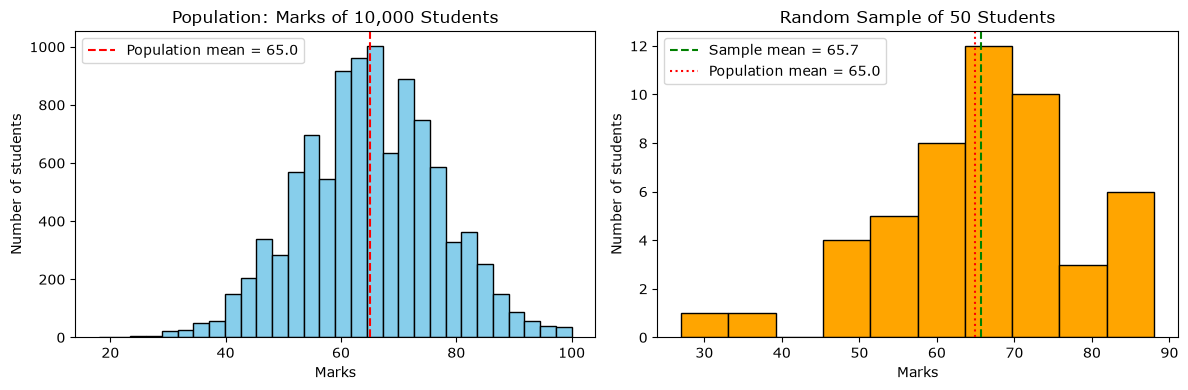

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)          # to get the same result every time

# Step 1: Create the population - marks of 10,000 students
population = np.random.normal(loc=65, scale=12, size=10000).round()
population = np.clip(population, 0, 100)      # marks must be between 0 and 100

# Step 2: Draw a simple random sample of 50 students (without replacement)
sample = np.random.choice(population, size=50, replace=False)

# Step 3: Compare population parameters and sample statistics
print("POPULATION  (N = 10000)")
print(f"  Population mean  (mu)    = {population.mean():.2f}")
print(f"  Population SD    (sigma) = {population.std():.2f}")

print("SAMPLE      (n = 50)")
print(f"  Sample mean      (x-bar) = {sample.mean():.2f}")
print(f"  Sample SD        (s)     = {sample.std(ddof=1):.2f}")
print(f"Sampling error (x-bar - mu) = {sample.mean() - population.mean():.2f}")

# Step 4: Different random samples give different sample means
print("\nMeans of 5 different random samples of size 50:")

for i in range(1, 6):
    s = np.random.choice(population, size=50, replace=False)
    print(f"  Sample {i}: mean = {s.mean():.2f}")

# Step 5: Graph
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Population graph
ax[0].hist(population, bins=30, color='skyblue', edgecolor='black')

ax[0].axvline(
    population.mean(),
    color='red',
    linestyle='--',
    label=f'Population mean = {population.mean():.1f}'
)

ax[0].set_title('Population: Marks of 10,000 Students')
ax[0].set_xlabel('Marks')
ax[0].set_ylabel('Number of students')
ax[0].legend()

# Sample graph
ax[1].hist(sample, bins=10, color='orange', edgecolor='black')

ax[1].axvline(
    sample.mean(),
    color='green',
    linestyle='--',
    label=f'Sample mean = {sample.mean():.1f}'
)

ax[1].axvline(
    population.mean(),
    color='red',
    linestyle=':',
    label=f'Population mean = {population.mean():.1f}'
)

ax[1].set_title('Random Sample of 50 Students')
ax[1].set_xlabel('Marks')
ax[1].set_ylabel('Number of students')
ax[1].legend()

plt.tight_layout()
plt.show()

Population mean = 40.04 min, Population SD = 7.99 min

    n   Mean of sample means    SE = σ/√n   SD of sample means
   10                  40.03         2.53                 2.49
   30                  40.06         1.46                 1.52
  100                  40.01         0.80                 0.81


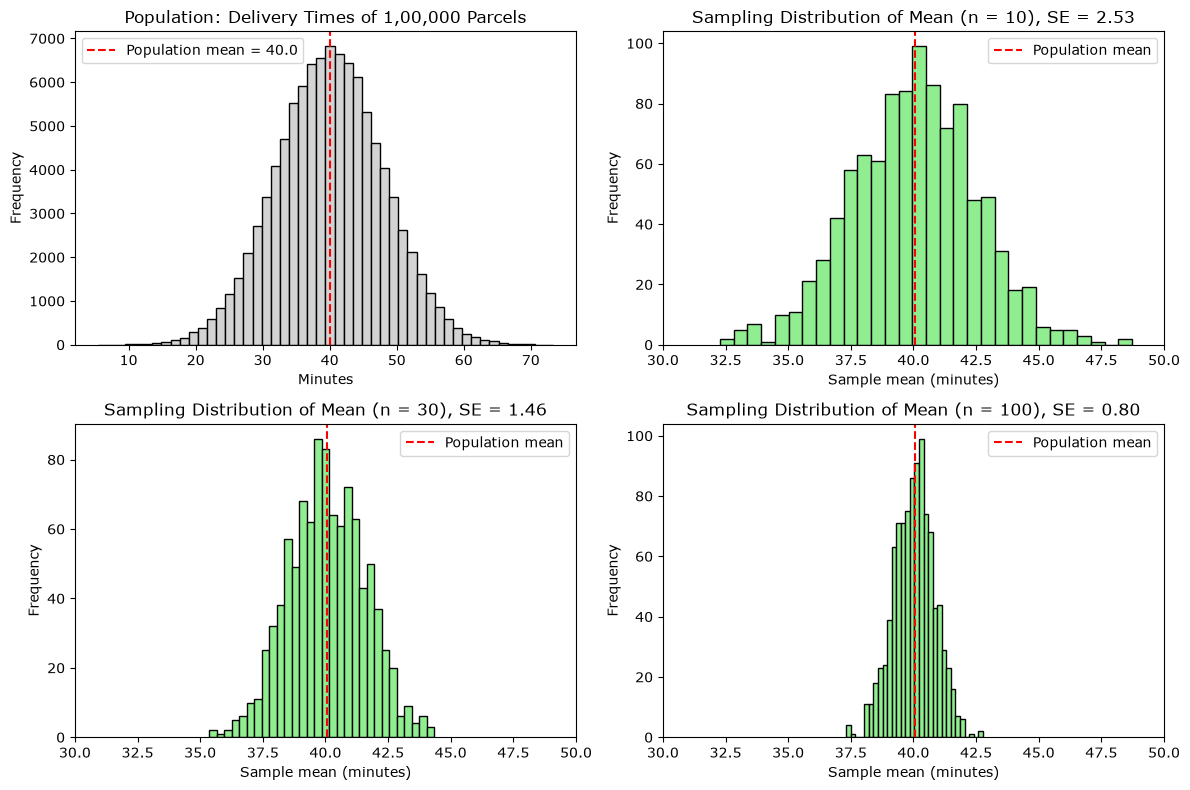


One sample of 30 parcels: mean = 39.50, estimated SE = s/√n = 1.28


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Step 1: Population of delivery times (minutes)
population = np.random.normal(loc=40, scale=8, size=100000)

mu, sigma = population.mean(), population.std()

print(f"Population mean = {mu:.2f} min, Population SD = {sigma:.2f} min\n")

# Step 2: Take 1000 samples for each sample size and store their means
sample_sizes = [10, 30, 100]
num_samples = 1000

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.ravel()

# Population histogram
ax[0].hist(population, bins=50, color='lightgray', edgecolor='black')

ax[0].axvline(
    mu,
    color='red',
    linestyle='--',
    label=f'Population mean = {mu:.1f}'
)

ax[0].set_title('Population: Delivery Times of 1,00,000 Parcels')
ax[0].set_xlabel('Minutes')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# Header
print(
    f"{'n':>5} "
    f"{'Mean of sample means':>22} "
    f"{'SE = σ/√n':>12} "
    f"{'SD of sample means':>20}"
)

# Sampling distributions
for i, n in enumerate(sample_sizes):

    sample_means = [
        np.random.choice(population, size=n, replace=False).mean()
        for _ in range(num_samples)
    ]

    se_formula = sigma / np.sqrt(n)
    se_observed = np.std(sample_means)

    print(
        f"{n:>5} "
        f"{np.mean(sample_means):>22.2f} "
        f"{se_formula:>12.2f} "
        f"{se_observed:>20.2f}"
    )

    ax[i + 1].hist(
        sample_means,
        bins=30,
        color='lightgreen',
        edgecolor='black'
    )

    ax[i + 1].axvline(
        mu,
        color='red',
        linestyle='--',
        label='Population mean'
    )

    # Same scale so spread can be compared
    ax[i + 1].set_xlim(30, 50)

    ax[i + 1].set_title(
        f'Sampling Distribution of Mean (n = {n}), SE = {se_formula:.2f}'
    )

    ax[i + 1].set_xlabel('Sample mean (minutes)')
    ax[i + 1].set_ylabel('Frequency')
    ax[i + 1].legend()

plt.tight_layout()
plt.show()

# Step 3: SE estimated from ONE sample of 30 parcels
# sigma is assumed unknown, so use sample SD (s)
one_sample = np.random.choice(
    population,
    size=30,
    replace=False
)

se_est = one_sample.std(ddof=1) / np.sqrt(30)

print(
    f"\nOne sample of 30 parcels: "
    f"mean = {one_sample.mean():.2f}, "
    f"estimated SE = s/√n = {se_est:.2f}"
)

Sample size (n)      = 36
Sample mean (x-bar)  = 496.67 g
Standard error       = 1.3333
Z statistic          = -2.5000
Critical value       = ±1.96
p-value              = 0.0124

Decision: |Z| > 1.96 -> Reject H0
Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.


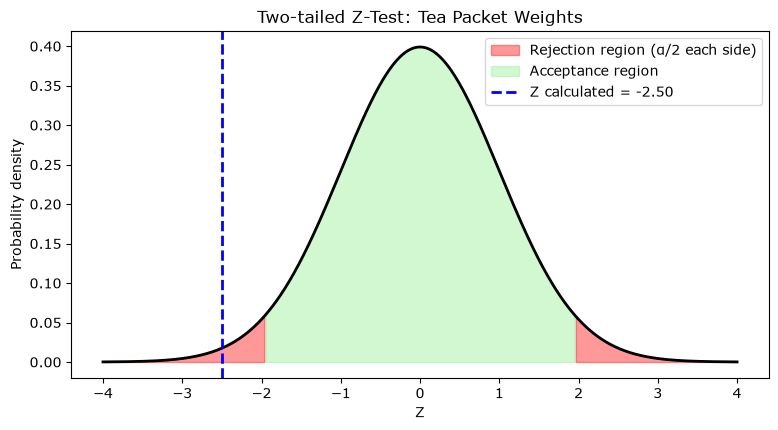

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - weights (g) of 36 packets
weights = np.array([
    495, 498, 492, 501, 497, 494, 499, 496, 503, 490, 497, 500,
    493, 498, 495, 502, 491, 497, 499, 494, 496, 500, 492, 498,
    497, 495, 501, 493, 496, 499, 494, 498, 502, 495, 497, 496
])

mu0 = 500        # claimed mean
sigma = 8        # known population SD
alpha = 0.05
n = len(weights)

x_bar = weights.mean()

# Step 2: Z statistic
se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se

# Step 3: Critical value and p-value (two-tailed)
z_critical = stats.norm.ppf(1 - alpha / 2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Sample size (n)      = {n}")
print(f"Sample mean (x-bar)  = {x_bar:.2f} g")
print(f"Standard error       = {se:.4f}")
print(f"Z statistic          = {z:.4f}")
print(f"Critical value       = ±{z_critical:.2f}")
print(f"p-value              = {p_value:.4f}")

# Step 4: Decision rule
if abs(z) > z_critical:
    print("\nDecision: |Z| > 1.96 -> Reject H0")
    print("Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.")
else:
    print("\nDecision: |Z| <= 1.96 -> Fail to reject H0")
    print("Interpretation: The machine is filling 500 g on average.")

# Step 5: Graph - standard normal curve with rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

plt.figure(figsize=(9, 4.5))

plt.plot(x, y, 'k', lw=2)

# Left rejection region
plt.fill_between(
    x,
    y,
    where=(x <= -z_critical),
    color='red',
    alpha=0.4,
    label='Rejection region (α/2 each side)'
)

# Right rejection region
plt.fill_between(
    x,
    y,
    where=(x >= z_critical),
    color='red',
    alpha=0.4
)

# Acceptance region
plt.fill_between(
    x,
    y,
    where=(abs(x) < z_critical),
    color='lightgreen',
    alpha=0.4,
    label='Acceptance region'
)

# Calculated Z
plt.axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z calculated = {z:.2f}'
)

plt.title('Two-tailed Z-Test: Tea Packet Weights')
plt.xlabel('Z')
plt.ylabel('Probability density')
plt.legend()

plt.show()

Z statistic = -1.7678

TWO-TAILED TEST  (H1: mu != 1000)
  Critical values = ±1.960,  p-value = 0.0771
  Decision: Fail to reject H0

LEFT-TAILED TEST (H1: mu < 1000)
  Critical value = -1.645,  p-value = 0.0385
  Decision: Reject H0

RIGHT-TAILED TEST (H1: mu > 1000)
  Critical value = 1.645, p-value = 0.9615
  Decision: Fail to reject H0


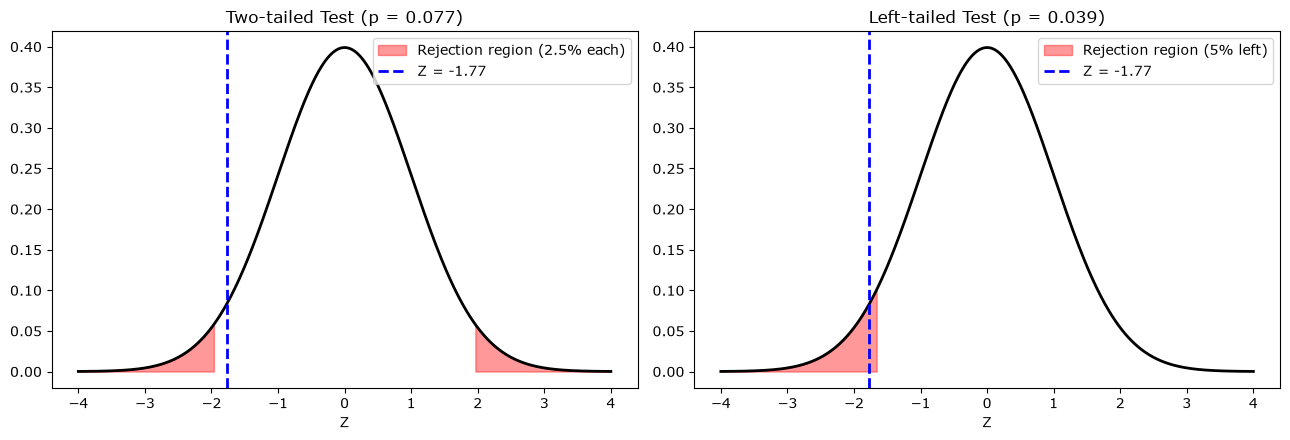

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Given summary data
mu0 = 1000      # claimed mean life (hours)
sigma = 100     # population SD
n = 50
x_bar = 975
alpha = 0.05

# Step 2: Z statistic (same for both tests)
z = (x_bar - mu0) / (sigma / np.sqrt(n))

print(f"Z statistic = {z:.4f}\n")

# Step 3: Two-tailed test
z_crit_two = stats.norm.ppf(1 - alpha / 2)
p_two = 2 * (1 - stats.norm.cdf(abs(z)))

print("TWO-TAILED TEST  (H1: mu != 1000)")
print(f"  Critical values = ±{z_crit_two:.3f},  p-value = {p_two:.4f}")
print(
    "  Decision:",
    "Reject H0" if p_two < alpha else "Fail to reject H0"
)

# Step 4: Left-tailed test
z_crit_left = stats.norm.ppf(alpha)
p_left = stats.norm.cdf(z)

print("\nLEFT-TAILED TEST (H1: mu < 1000)")
print(f"  Critical value = {z_crit_left:.3f},  p-value = {p_left:.4f}")
print(
    "  Decision:",
    "Reject H0" if p_left < alpha else "Fail to reject H0"
)

# Step 5: Right-tailed test (for comparison only)
p_right = 1 - stats.norm.cdf(z)

print("\nRIGHT-TAILED TEST (H1: mu > 1000)")
print(
    f"  Critical value = {stats.norm.ppf(1 - alpha):.3f}, "
    f"p-value = {p_right:.4f}"
)
print(
    "  Decision:",
    "Reject H0" if p_right < alpha else "Fail to reject H0"
)

# Step 6: Graph - two-tailed vs left-tailed rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Two-tailed graph
ax[0].plot(x, y, 'k', lw=2)

ax[0].fill_between(
    x,
    y,
    where=(x <= -z_crit_two),
    color='red',
    alpha=0.4,
    label='Rejection region (2.5% each)'
)

ax[0].fill_between(
    x,
    y,
    where=(x >= z_crit_two),
    color='red',
    alpha=0.4
)

ax[0].axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z = {z:.2f}'
)

ax[0].set_title(f'Two-tailed Test (p = {p_two:.3f})')
ax[0].set_xlabel('Z')
ax[0].legend(loc='upper right')

# Left-tailed graph
ax[1].plot(x, y, 'k', lw=2)

ax[1].fill_between(
    x,
    y,
    where=(x <= z_crit_left),
    color='red',
    alpha=0.4,
    label='Rejection region (5% left)'
)

ax[1].axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z = {z:.2f}'
)

ax[1].set_title(f'Left-tailed Test (p = {p_left:.3f})')
ax[1].set_xlabel('Z')
ax[1].legend()

plt.tight_layout()
plt.show()